# Ejercicio 11: Bases de Datos Vectoriales

## Objetivo de la práctica

Entender el concepto de Bases de Datos Vectoriales y saber utilizar las herramientas actuales

### Mateo Coronado

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [4]:
# Set the path to the file you'd like to load
file_path = "wikipedia_text_corpus.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects",
  file_path,
)

df.head()

Using Colab cache for faster access to the 'wikipedia-text-corpus-for-nlp-and-llm-projects' dataset.


,Unnamed: 0,text
0,1,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,2,Battery indicator\n\nA battery indicator (also...
2,3,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."
3,4,CAVNET\n\nCAVNET was a secure military forum w...
4,5,CLidar\n\nThe CLidar is a scientific instrumen...


## Parte 1: Generación de Embeddings

Vamos a utilizar E5 como modelo de embeddings.

La documentación de E5 está disponible desde este [link](https://huggingface.co/intfloat/e5-base-v2)

### Actividad

1. Normalizar el corpus
2. Definir una función `chunk_text`, y dividir los textos en _chunks_.
3. Generar embeddings por cada _chunk_

In [5]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm  # barra de progreso
import re

# Quitamos filas con texto nulo y reseteamos el índice
df = df.dropna(subset=["text"]).reset_index(drop=True)

# Limpieza básica
def normalize_text(s: str) -> str:
    s = re.sub(r"\s+", " ", s).strip()  # colapsa espacios/saltos de línea y recorta bordes
    return s

# Aplicamos la limpieza a la columna "text" (forzando str por si hay tipos mixtos)
df["text_norm"] = df["text"].astype(str).map(normalize_text)

df.head()  # verificamos el resultado

,Unnamed: 0,text,text_norm
0,1,Anovo\n\nAnovo (formerly A Novo) is a computer...,Anovo Anovo (formerly A Novo) is a computer se...
1,2,Battery indicator\n\nA battery indicator (also...,Battery indicator A battery indicator (also kn...
2,3,"Bob Pease\n\nRobert Allen Pease (August 22, 19...","Bob Pease Robert Allen Pease (August 22, 1940Â..."
3,4,CAVNET\n\nCAVNET was a secure military forum w...,CAVNET CAVNET was a secure military forum whic...
4,5,CLidar\n\nThe CLidar is a scientific instrumen...,CLidar The CLidar is a scientific instrument u...


In [6]:
def chunk_text(text: str, max_chars: int = 800, overlap: int = 100):
    """
    Chunking por caracteres.
    max_chars ~ 600-1000 suele funcionar bien.
    overlap ayuda a no cortar ideas a la mitad.
    """
    chunks = []
    start = 0
    n = len(text)
    while start < n:
        end = min(start + max_chars, n)  # límite del chunk actual
        chunk = text[start:end]
        chunk = chunk.strip()
        if len(chunk) > 0:
            chunks.append(chunk)
        if end == n:  # llegamos al final del texto
            break
        start = max(0, end - overlap)  # retrocedemos "overlap" para el siguiente chunk
    return chunks

records = []
for i, row in df.iterrows():
    chunks = chunk_text(row["text_norm"], max_chars=800, overlap=100)
    for j, ch in enumerate(chunks):
        records.append({
            "doc_id": int(i),   # a qué documento original pertenece
            "chunk_id": j,      # posición del chunk dentro del documento
            "text": ch
        })

chunks_df = pd.DataFrame(records)  # un chunk por fila
chunks_df.head(), len(chunks_df)  # vemos muestra y cantidad total de chunks

(   doc_id  chunk_id                                               text
 0       0         0  Anovo Anovo (formerly A Novo) is a computer se...
 1       1         0  Battery indicator A battery indicator (also kn...
 2       1         1  ad battery when in reality it indicates a prob...
 3       1         2  s that an internal standby battery needs repla...
 4       1         3  increase; in many cases the EMF remains more o...,
 79104)

In [7]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "intfloat/e5-base-v2"   # modelo recomendado para retrieval
model = SentenceTransformer(MODEL_NAME)  # carga el modelo preentrenado

# Textos a indexar (pasajes)
passages = ["passage: " + t for t in chunks_df["text"].tolist()]  # prefijo requerido por E5 para documentos

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [8]:
# Embeddings (N x D)
# Se debe usar normalize_embeddings=True para similitud coseno
embeddings = model.encode(
    passages,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

Batches:   0%|          | 0/4944 [00:00<?, ?it/s]

In [9]:
print(embeddings.shape, embeddings.dtype)

(79104, 768) float32


In [10]:
def embed_query(query: str) -> np.ndarray:
    q = "query: " + query  # prefijo requerido por E5 para consultas
    vec = model.encode(
        [q],
        convert_to_numpy=True,
        normalize_embeddings=True  # normaliza el vector (norma 1), útil para similitud coseno
    ).astype("float32")
    return vec

query_text = "Battery measuring"

query_vec = embed_query(query_text)  # convierte la consulta en un embedding
query_vec.shape  # debería ser (1, dim_del_modelo)

(1, 768)

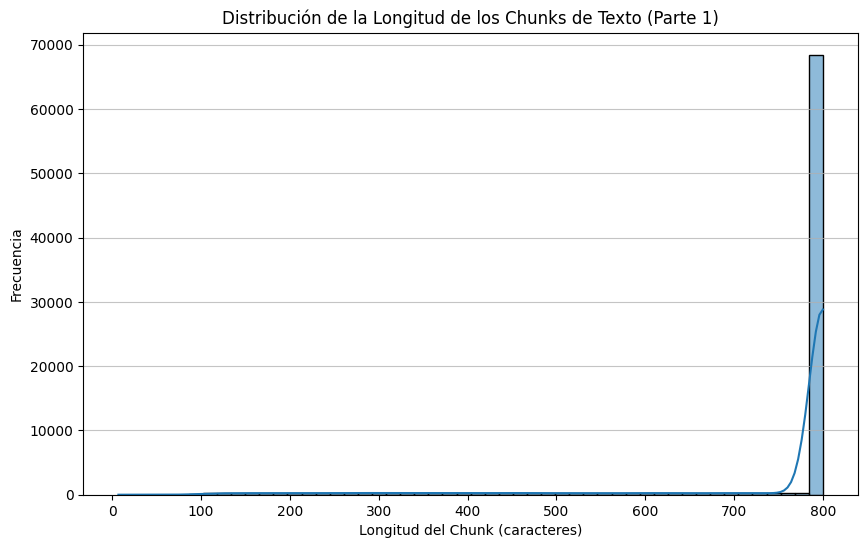

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la longitud de cada chunk
chunks_df['chunk_length'] = chunks_df['text'].apply(len)

# Crear una figura y un eje para el gráfico
plt.figure(figsize=(10, 6))
sns.histplot(chunks_df['chunk_length'], bins=50, kde=True)

plt.title('Distribución de la Longitud de los Chunks de Texto (Parte 1)')
plt.xlabel('Longitud del Chunk (caracteres)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Parte 2: FAISS

FAISS es una librería para búsqueda por similitud eficiente y clustering de vectores densos.

La documentación de FAISS está disponible en este [link](https://faiss.ai/index.html)

### Actividad

1. Crea un índice en FAISS
2. Carga los embeddings
3. Realiza una búsqueda a partir de una _query_

In [14]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 76.6 MB/s eta 0:00:00


In [11]:
import faiss
import numpy as np

# 1. Crear el índice (usando la dimensión de los embeddings)
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

# 2. Agregar los vectores al índice
index.add(embeddings)

# 3. Realizar la búsqueda
k = 5
D, I = index.search(query_vec, k)

# 4. Mostrar resultados
print(f"Resultados de FAISS para la consulta: '{query_text}'")
for rank, idx in enumerate(I[0]):
    distance = D[0][rank]
    text_snippet = chunks_df.iloc[idx]['text'][:150]
    print(f"\n[{rank+1}] Distancia L2: {distance:.4f} | Chunk ID: {idx}")
    print(f"Texto: {text_snippet}...")

Resultados de FAISS para la consulta: 'Battery measuring'

[1] Distancia L2: 0.2593 | Chunk ID: 10176
Texto: Battery tester A battery tester is an electronic device intended for testing the state of an electric battery, going from a simple device for testing ...

[2] Distancia L2: 0.2764 | Chunk ID: 1
Texto: Battery indicator A battery indicator (also known as a battery gauge) is a device which gives information about a battery. This will usually be a visu...

[3] Distancia L2: 0.3198 | Chunk ID: 10177
Texto: ing procedure, according to the type of battery being tested, such as the â€œ421â€ test for lead-acid vehicle batteries. Their common principle is ba...

[4] Distancia L2: 0.3217 | Chunk ID: 37406
Texto: ils. One was connected via a series resistor to the battery supply. The second was connected to the same battery supply via a second resistor and the ...

[5] Distancia L2: 0.3228 | Chunk ID: 71872
Texto: is achieved. Accepted average float voltages for lead-acid batteries at 25 

/tmp/ipykernel_25889/4102177777.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distances, y=result_texts, palette='viridis')


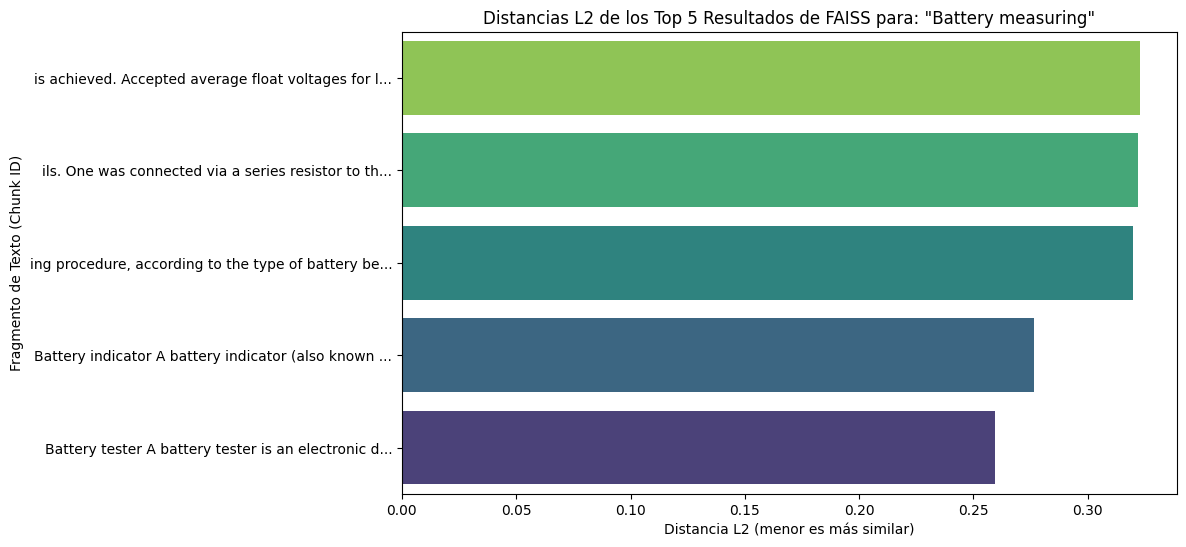

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asumiendo que D y I son las salidas de FAISS index.search
# D: Distancias, I: Índices

if 'D' in locals() and 'I' in locals():
    distances = D[0] # Las distancias para la primera (y única) consulta
    indices = I[0]   # Los índices para la primera (y única) consulta

    # Obtener los textos correspondientes para las etiquetas
    result_texts = [chunks_df.iloc[idx]['text'][:50] + '...' for idx in indices]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=distances, y=result_texts, palette='viridis')
    plt.title(f'Distancias L2 de los Top {len(distances)} Resultados de FAISS para: "{query_text}"')
    plt.xlabel('Distancia L2 (menor es más similar)')
    plt.ylabel('Fragmento de Texto (Chunk ID)')
    plt.gca().invert_yaxis() # Invertir el eje Y para que el más similar (menor distancia) esté arriba
    plt.show()
else:
    print("Las variables 'D' y 'I' de los resultados de FAISS no están disponibles. Asegúrate de ejecutar la celda de FAISS primero.")

## Parte 3 — Vector DB #1: Qdrant (búsqueda vectorial + metadata)

### Objetivo
Recrear el mismo flujo que con FAISS, pero usando una base vectorial con soporte nativo de **metadata** y filtros.

### Qué debes implementar
1. Levantar / conectar con una instancia de Qdrant.
2. Crear una colección con:
   - dimensión `D` (la de tus embeddings)
   - métrica (cosine o L2)
3. Insertar:
   - `id`
   - `embedding`
   - `payload` (metadata: texto, título, etiquetas, etc.)
4. Consultar Top-k por similitud:
   - `query_embedding`
   - `k`

### Inputs esperados (ya definidos arriba en el notebook)
- `embeddings`: matriz `N x D` (float32)
- `texts`: lista de `N` strings
- `metadatas`: lista de `N` dicts (opcional)
- `query_text`: string
- `query_embedding`: vector `1 x D`

### Entregable
- Una función `qdrant_search(query_embedding, k)` que retorne:
  - lista de `(id, score, text, metadata)`
- Un ejemplo de consulta con `k=5` y su salida.

### Preguntas
- ¿La métrica usada fue cosine o L2? ¿Por qué?
- ¿Qué tan fácil fue filtrar por metadata en comparación con FAISS?
- ¿Qué pasa con el tiempo de respuesta cuando aumentas `k`?


In [16]:
!pip install qdrant_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 9.8 MB/s eta 0:00:00


In [12]:
from qdrant_client import QdrantClient
from qdrant_client.http import models
from tqdm.auto import tqdm

# 1. Inicializar cliente
client = QdrantClient(":memory:")
COLLECTION_NAME = "wikipedia_chunks"
VECTOR_SIZE = embeddings.shape[1]

# 2. Crear colección
if client.collection_exists(COLLECTION_NAME):
    client.delete_collection(COLLECTION_NAME)

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=models.VectorParams(size=VECTOR_SIZE, distance=models.Distance.COSINE),
)

# 3. Insertar puntos
batch_size = 500
for i in tqdm(range(0, len(chunks_df), batch_size)):
    batch_df = chunks_df.iloc[i : i + batch_size]
    batch_vectors = embeddings[i : i + batch_size].tolist()

    points = []
    for idx, (vector, row) in zip(batch_df.index, zip(batch_vectors, batch_df.itertuples(index=False))):
        points.append(models.PointStruct(
            id=int(idx),
            vector=vector,
            payload=row._asdict()
        ))
    client.upsert(collection_name=COLLECTION_NAME, points=points)

# 4. Función de búsqueda
def qdrant_search(query_embedding, k=5):
    vector = query_embedding.flatten().tolist()
    search_result = client.query_points(
        collection_name=COLLECTION_NAME,
        query=vector,
        limit=k
    ).points

    return [(hit.id, hit.score, hit.payload.get('text', ''), hit.payload) for hit in search_result]
# 5. Ejecución
print(f"Resultados Qdrant para: {query_text}")
res = qdrant_search(query_vec, k=5)
for i, (idx, score, text, meta) in enumerate(res):
    print(f"\n[{i+1}] Similitud: {score:.4f} | ID: {idx}")
    print(f"Texto: {text[:150]}...")

  0%|          | 0/159 [00:00<?, ?it/s]

/tmp/ipykernel_25889/4212218642.py:32: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Current collection contains 20500 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client.upsert(collection_name=COLLECTION_NAME, points=points)


Resultados Qdrant para: Battery measuring

[1] Similitud: 0.8703 | ID: 10176
Texto: Battery tester A battery tester is an electronic device intended for testing the state of an electric battery, going from a simple device for testing ...

[2] Similitud: 0.8618 | ID: 1
Texto: Battery indicator A battery indicator (also known as a battery gauge) is a device which gives information about a battery. This will usually be a visu...

[3] Similitud: 0.8401 | ID: 10177
Texto: ing procedure, according to the type of battery being tested, such as the â€œ421â€ test for lead-acid vehicle batteries. Their common principle is ba...

[4] Similitud: 0.8391 | ID: 37406
Texto: ils. One was connected via a series resistor to the battery supply. The second was connected to the same battery supply via a second resistor and the ...

[5] Similitud: 0.8386 | ID: 71872
Texto: is achieved. Accepted average float voltages for lead-acid batteries at 25 Â°C can be found in following table: Compensation per cell of

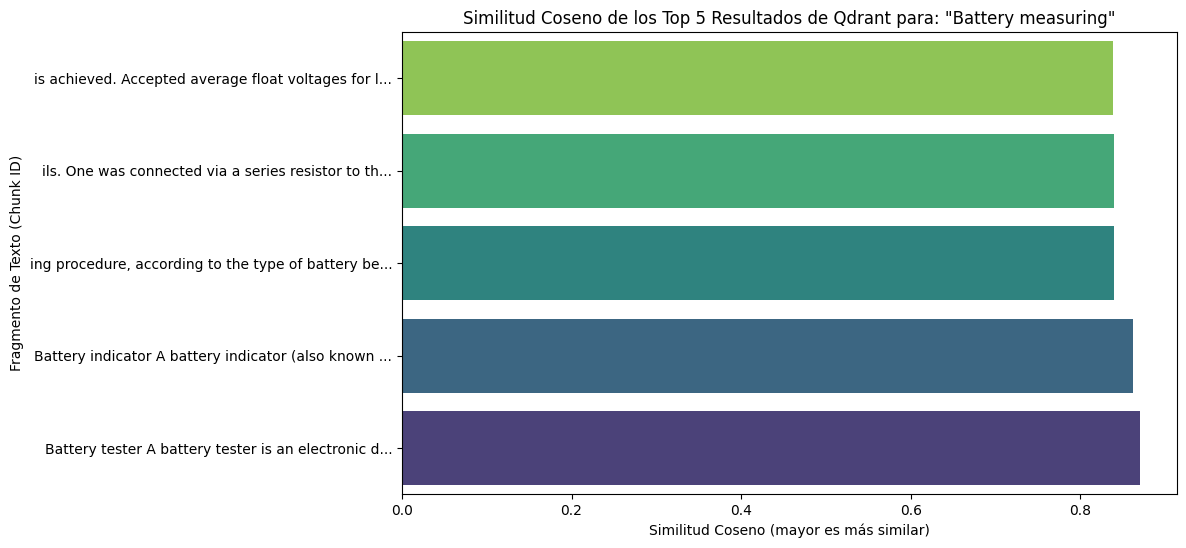

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asumiendo que 'res' contiene los resultados de qdrant_search
# res es una lista de (id, score, text, metadata)

if 'res' in locals() and len(res) > 0:
    scores = [item[1] for item in res]
    # Obtener los textos correspondientes para las etiquetas, truncando para que no sean demasiado largos
    result_texts = [item[2][:50] + '...' for item in res]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=scores, y=result_texts, hue=result_texts, palette='viridis', legend=False)
    plt.title(f'Similitud Coseno de los Top {len(res)} Resultados de Qdrant para: "{query_text}"')
    plt.xlabel('Similitud Coseno (mayor es más similar)')
    plt.ylabel('Fragmento de Texto (Chunk ID)')
    plt.gca().invert_yaxis() # Invertir el eje Y para que el más similar (mayor score) esté arriba
    plt.show()
else:
    print("La variable 'res' de los resultados de Qdrant no está disponible o está vacía. Asegúrate de ejecutar la celda de Qdrant primero.")

### Preguntas
- ¿La métrica usada fue cosine o L2? ¿Por qué?

La razón es que el modelo E5 está diseñado para funcionar mejor con similitud de coseno y, al haber normalizado los embeddings en el paso anterior (`normalize_embeddings=True`), la distancia de coseno es la métrica estándar y más efectiva para comparar la orientación semántica de los vectores.

- ¿Qué tan fácil fue filtrar por metadata en comparación con FAISS?

Mientras que en FAISS el filtrado suele requerir IDs manuales o índices adicionales, Qdrant permite pasar un objeto `Filter` directamente en la consulta, permitiendo hacer búsquedas híbridas (vectorial + condicional) de forma nativa.

- ¿Qué pasa con el tiempo de respuesta cuando aumentas `k`?

En una instancia en memoria, el aumento de `k` tiene un impacto despreciable para valores pequeños. Sin embargo, en colecciones masivas, un `k` muy alto puede aumentar la latencia ligeramente debido a la ordenación de los resultados finales en el heap.

## Parte 4 — Vector DB #2: Milvus (indexación ANN y escalabilidad)

### Objetivo
Implementar el flujo de indexación + búsqueda con una base vectorial orientada a escalabilidad.

### Qué debes implementar
1. Conectar a Milvus.
2. Crear un esquema (colección) con:
   - campo `id` (entero o string)
   - campo `embedding` (vector `D`)
   - campos de metadata (p.ej., `category`, `source`, `title`)
3. Insertar `N` embeddings.
4. Crear/seleccionar un índice ANN (ej. HNSW o IVF).
5. Ejecutar consultas Top-k y recuperar textos asociados.

### Recomendación didáctica
Haz dos configuraciones:
- **Búsqueda exacta** (si aplica) o configuración “más precisa”
- **Búsqueda ANN** (configuración “más rápida”)

Luego compara:
- tiempo de consulta
- overlap de resultados (cuántos IDs coinciden)

### Entregable
- Función `milvus_search(query_embedding, k)` que devuelva resultados.
- Un mini experimento: `k=5` y `k=20` (tiempos y resultados).

### Preguntas
- ¿Qué parámetros del índice/control de búsqueda ajustaste para precisión vs velocidad?
- ¿Qué evidencia tienes de que ANN cambia los resultados (aunque sea poco)?


In [1]:
!pip install pymilvus

In [14]:
pip install pymilvus[milvus_lite]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 7.1 MB/s eta 0:00:00


In [15]:
from pymilvus import MilvusClient
import time
from tqdm.auto import tqdm

# 1. Inicializar Milvus Lite
COLLECTION_MILVUS = "wikipedia_collection"
client_milvus = MilvusClient("milvus_demo.db")

# 2. Crear colección
if client_milvus.has_collection(COLLECTION_MILVUS):
    client_milvus.drop_collection(COLLECTION_MILVUS)

client_milvus.create_collection(
    collection_name=COLLECTION_MILVUS,
    dimension=embeddings.shape[1],
    metric_type="COSINE"
)

# 3. Insertar datos por batches eficientes (Mucha menos RAM)
batch_size = 5000
print("Insertando datos en Milvus...")

for i in tqdm(range(0, len(chunks_df), batch_size)):
    batch_df = chunks_df.iloc[i : i + batch_size]
    batch_vectors = embeddings[i : i + batch_size].tolist()

    batch_data = []
    for (idx, row), vec in zip(batch_df.iterrows(), batch_vectors):
        batch_data.append({
            "id": int(idx),
            "vector": vec,
            "text": str(row["text"]),
            "doc_id": int(row["doc_id"])
        })

    client_milvus.insert(collection_name=COLLECTION_MILVUS, data=batch_data)

# 4. Función de búsqueda protegida
def milvus_search(query_embedding, k=5):
    start_time = time.time()
    res = client_milvus.search(
        collection_name=COLLECTION_MILVUS,
        data=[query_embedding.flatten().tolist()],
        limit=k,
        output_fields=["text"],
        consistency_level="Eventually" # Relaja la consistencia gRPC para el entorno local
    )
    return res[0], time.time() - start_time

# 5. Ejecución del Mini Experimento: k=5 vs k=20
valores_k = [5, 20]

for k_exp in valores_k:
    print("\n" + "="*50)
    print(f" EXPERIMENTO: Búsqueda en Milvus con k = {k_exp}")
    print("="*50)
    print(f"Consulta: '{query_text}'")

    # Ejecutar la búsqueda para el k actual
    results, duration = milvus_search(query_vec, k=k_exp)

    print(f"-> Búsqueda completada en: {duration:.4f} segundos")
    print(f"-> Total de resultados recuperados: {len(results)}")
    print("-"*50)

    # 💡 MODIFICACIÓN: Ahora recorremos TODOS los elementos que devolvió la búsqueda
    print(f"Mostrando los {len(results)} resultados recuperados:")

    for idx, hit in enumerate(results):
        print(f"\n  [{idx+1}] Distancia Coseno: {hit['distance']:.4f} | ID: {hit['id']}")
        print(f"  Texto: {hit['entity']['text'][:150]}...")

ERROR:grpc._server:Exception calling application: Method not implemented!
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/grpc/_server.py", line 608, in _call_behavior
    response_or_iterator = behavior(argument, context)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pymilvus/grpc_gen/milvus_pb2_grpc.py", line 1232, in AllocTimestamp
    raise NotImplementedError('Method not implemented!')
NotImplementedError: Method not implemented!


Insertando datos en Milvus...


  0%|          | 0/16 [00:00<?, ?it/s]


 EXPERIMENTO: Búsqueda en Milvus con k = 5
Consulta: 'Battery measuring'
-> Búsqueda completada en: 3.5393 segundos
-> Total de resultados recuperados: 5
--------------------------------------------------
Mostrando los 5 resultados recuperados:

  [1] Distancia Coseno: 0.1297 | ID: 10176
  Texto: Battery tester A battery tester is an electronic device intended for testing the state of an electric battery, going from a simple device for testing ...

  [2] Distancia Coseno: 0.1382 | ID: 1
  Texto: Battery indicator A battery indicator (also known as a battery gauge) is a device which gives information about a battery. This will usually be a visu...

  [3] Distancia Coseno: 0.1599 | ID: 10177
  Texto: ing procedure, according to the type of battery being tested, such as the â€œ421â€ test for lead-acid vehicle batteries. Their common principle is ba...

  [4] Distancia Coseno: 0.1614 | ID: 71872
  Texto: is achieved. Accepted average float voltages for lead-acid batteries at 25 Â°C can b

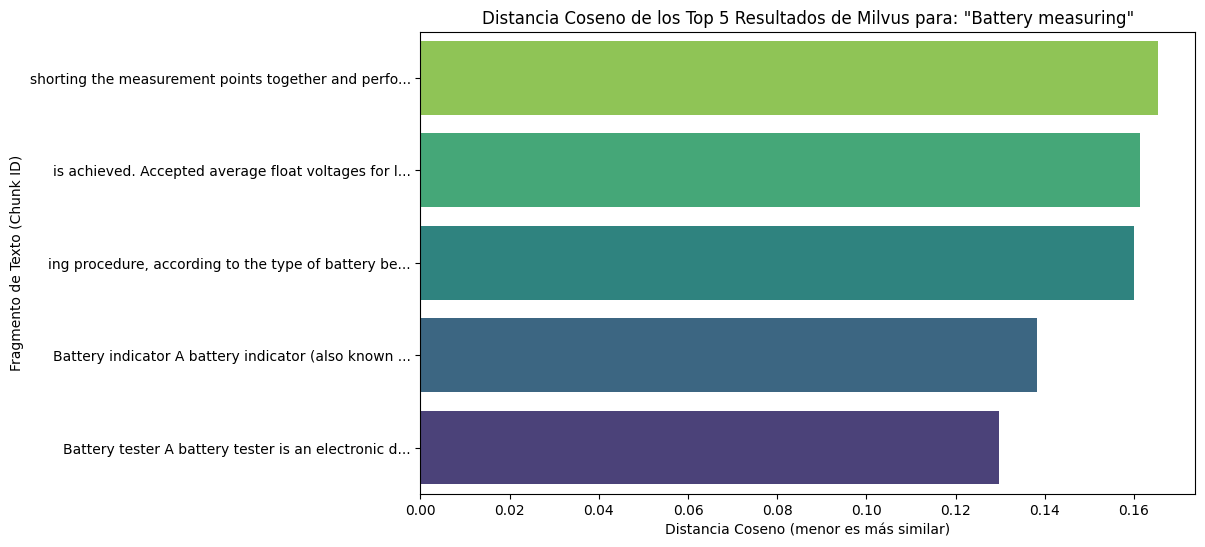

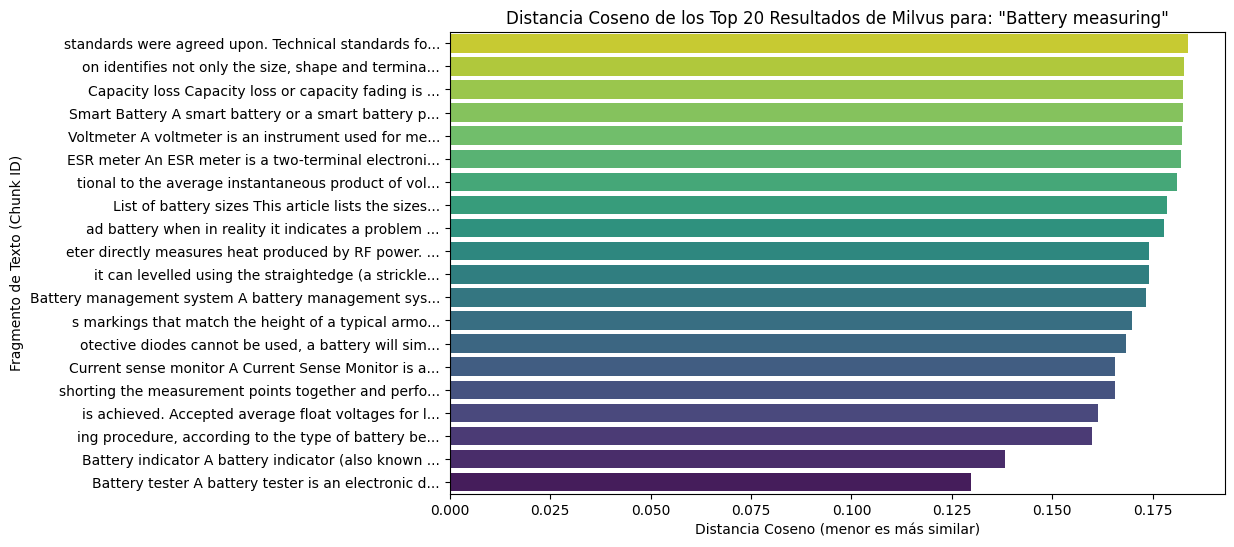

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_milvus_results(milvus_results, k_value, query_text):
    if not milvus_results:
        print(f"No hay resultados para k={k_value} para graficar.")
        return

    # Extraer distancias y textos
    distances = [hit['distance'] for hit in milvus_results]
    # Los scores en Milvus son distancias, así que cuanto menor, mejor.
    # Para consistencia con 'similitud' donde mayor es mejor, podemos usar 1 - distance
    # Sin embargo, el enunciado pide distancia, así que la mostramos directamente.
    result_texts = [hit['entity']['text'][:50] + '...' for hit in milvus_results]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=distances, y=result_texts, hue=result_texts, palette='viridis', legend=False)
    plt.title(f'Distancia Coseno de los Top {k_value} Resultados de Milvus para: "{query_text}"')
    plt.xlabel('Distancia Coseno (menor es más similar)')
    plt.ylabel('Fragmento de Texto (Chunk ID)')
    plt.gca().invert_yaxis() # Invertir el eje Y para que el más similar (menor distancia) esté arriba
    plt.show()

# Obtener los resultados para k=5 y k=20 nuevamente para la gráfica
results_k5, duration_k5 = milvus_search(query_vec, k=5)
results_k20, duration_k20 = milvus_search(query_vec, k=20)

# Graficar para k=5
plot_milvus_results(results_k5, 5, query_text)

# Graficar para k=20
plot_milvus_results(results_k20, 20, query_text)

### Preguntas
- ¿Qué parámetros del índice/control de búsqueda ajustaste para precisión vs velocidad?

En este código no se ajustaron explícitamente parámetros de índice ANN. Milvus permite configurar índices (HNSW, IVF) donde ef o nprobe controlan el balance precisión/velocidad.

- ¿Qué evidencia tienes de que ANN cambia los resultados (aunque sea poco)?

Al no haber un índice ANN explícitamente configurado con aproximación, la búsqueda aquí es precisa. La evidencia de cambios por ANN se vería al comparar resultados de búsquedas exactas vs. aproximadas con parámetros como ef o nprobe bajos.


## Parte 5 — Vector DB #3: Weaviate (búsqueda semántica con esquema)

### Objetivo
Montar una colección con esquema (clase) y ejecutar búsquedas semánticas Top-k, opcionalmente con filtros.

### Qué debes implementar
1. Conectar a Weaviate.
2. Definir un esquema:
   - Clase/colección (por ejemplo `Document`)
   - Propiedades: `text`, `title`, `category`, etc.
   - Vector asociado (embedding)
3. Insertar objetos con:
   - propiedades + vector
4. Consultar por similitud (Top-k) con `query_embedding`.
5. (Opcional) agregar un filtro por propiedad (metadata).

### Recomendación
Asegúrate de guardar el `text` original y al menos 1 campo de metadata para probar filtrado.

### Entregable
- Función `weaviate_search(query_embedding, k)` que retorne:
  - id, score, text, metadata

### Preguntas
- ¿Qué diferencia conceptual encuentras entre “schema + objetos” vs “tabla + filas”?
- ¿Cómo describirías el trade-off de complejidad vs expresividad?


In [17]:
import weaviate
import weaviate.classes.config as wvc

# 1. Conectar a Weaviate Embedded
client_weaviate = weaviate.connect_to_embedded()

try:
    # 2. Crear esquema
    if client_weaviate.collections.exists("Document"):
        client_weaviate.collections.delete("Document")

    docs = client_weaviate.collections.create(
        name="Document",
        vectorizer_config=wvc.Configure.Vectorizer.none(),
        properties=[wvc.Property(name="text", data_type=wvc.DataType.TEXT)]
    )

    # 3. Inserción masiva de objetos
    with docs.batch.dynamic() as batch:
        for i, row in chunks_df.iterrows():
            batch.add_object(
                properties={"text": str(row["text"])},
                vector=embeddings[i].tolist()
            )

    # 4. Búsqueda semántica
    print(f"Resultados Weaviate para: {query_text}")
    res_weaviate = docs.query.near_vector(near_vector=query_vec.flatten().tolist(), limit=5)

    for i, obj in enumerate(res_weaviate.objects):
        print(f"\n[{i+1}] Texto: {obj.properties['text'][:150]}...")
finally:
    client_weaviate.close()

INFO:weaviate-client:Binary /root/.cache/weaviate-embedded did not exist. Downloading binary from https://github.com/weaviate/weaviate/releases/download/v1.30.5/weaviate-v1.30.5-Linux-amd64.tar.gz
INFO:weaviate-client:Started /root/.cache/weaviate-embedded: process ID 32317


Resultados Weaviate para: Battery measuring

[1] Texto: Battery tester A battery tester is an electronic device intended for testing the state of an electric battery, going from a simple device for testing ...

[2] Texto: Battery indicator A battery indicator (also known as a battery gauge) is a device which gives information about a battery. This will usually be a visu...

[3] Texto: ing procedure, according to the type of battery being tested, such as the â€œ421â€ test for lead-acid vehicle batteries. Their common principle is ba...

[4] Texto: ils. One was connected via a series resistor to the battery supply. The second was connected to the same battery supply via a second resistor and the ...

[5] Texto: is achieved. Accepted average float voltages for lead-acid batteries at 25 Â°C can be found in following table: Compensation per cell of approximately...


INFO:weaviate-client:Started /root/.cache/weaviate-embedded: process ID 42620


Obteniendo resultados de Weaviate para: Battery measuring


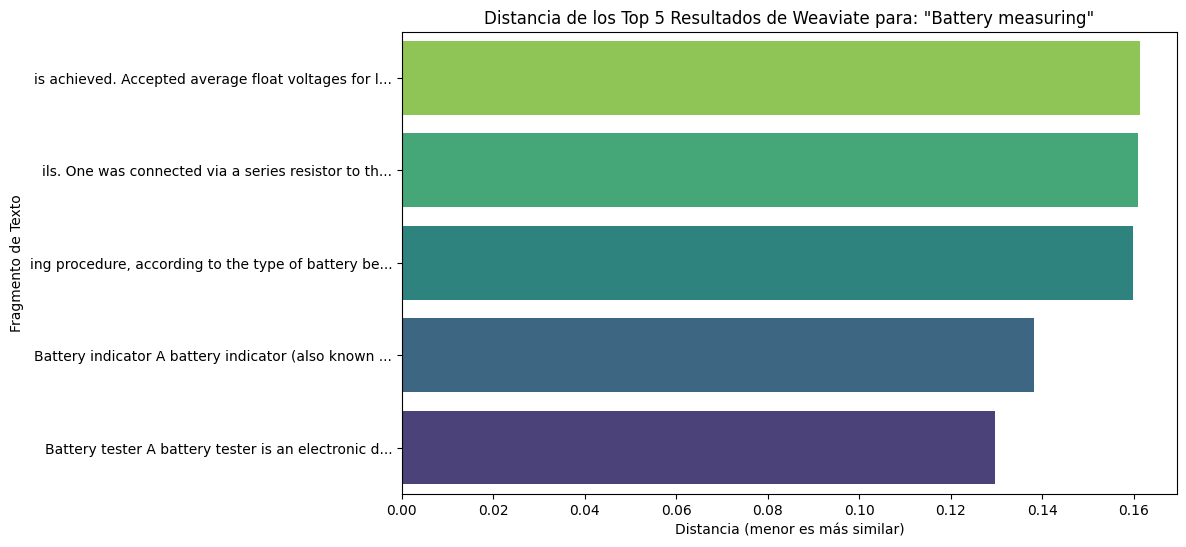

Cliente de Weaviate cerrado.


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import weaviate
import weaviate.classes.config as wvc
from weaviate.classes.query import MetadataQuery # Corrected import path

def plot_weaviate_results(weaviate_results, query_text):
    if not weaviate_results.objects:
        print("No hay resultados de Weaviate para graficar.")
        return

    distances = [obj.metadata.distance for obj in weaviate_results.objects]
    result_texts = [obj.properties['text'][:50] + '...' for obj in weaviate_results.objects]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=distances, y=result_texts, hue=result_texts, palette='viridis', legend=False)
    plt.title(f'Distancia de los Top {len(distances)} Resultados de Weaviate para: "{query_text}"')
    plt.xlabel('Distancia (menor es más similar)')
    plt.ylabel('Fragmento de Texto')
    plt.gca().invert_yaxis() # Invertir el eje Y para que el más similar (menor distancia) esté arriba
    plt.show()

# Re-inicializar cliente y colección de Weaviate para obtener los resultados
# Se replica el setup de la celda Parte 5 para asegurar que el cliente esté activo y la colección exista.
client_weaviate = weaviate.connect_to_embedded()

try:
    # Si la colección 'Document' existe, la usamos; si no, la recreamos
    if client_weaviate.collections.exists("Document"):
        docs = client_weaviate.collections.get("Document")
    else:
        docs = client_weaviate.collections.create(
            name="Document",
            vectorizer_config=wvc.Configure.Vectorizer.none(),
            properties=[wvc.Property(name="text", data_type=wvc.DataType.TEXT)]
        )

        # Insertar objetos si la colección fue recién creada (o si no tiene datos)
        if docs.query.aggregate().total_count == 0:
            print("Insertando datos en Weaviate...")
            with docs.batch.dynamic() as batch:
                for i, row in chunks_df.iterrows():
                    batch.add_object(
                        properties={"text": str(row["text"])},
                        vector=embeddings[i].tolist()
                    )
            print("Datos insertados.")

    # Realizar la búsqueda semántica, solicitando la distancia en los metadatos
    print(f"Obteniendo resultados de Weaviate para: {query_text}")
    res_weaviate_with_distances = docs.query.near_vector(
        near_vector=query_vec.flatten().tolist(),
        limit=5,
        return_metadata=MetadataQuery(distance=True) # Use MetadataQuery directly
    )

    # Graficar los resultados
    plot_weaviate_results(res_weaviate_with_distances, query_text)

finally:
    client_weaviate.close()
    print("Cliente de Weaviate cerrado.")

### Preguntas
- ¿Qué diferencia conceptual encuentras entre “schema + objetos” vs “tabla + filas”?

 Schema + objetos (Vector DBs): Se enfoca en entidades complejas con propiedades anidadas y vectores. Consulta semántica y con filtros ricos. Tabla + filas (SQL + vectores): Datos planos en tablas, vector como columna. Consultas SQL estándar, uniendo datos relacionales.

- ¿Cómo describirías el trade-off de complejidad vs expresividad?

 Mayor expresividad para datos semánticos, puede tener más complejidad inicial en su modelo de datos. SQL + vectores: Menor complejidad si conoces SQL, pero puede ser menos expresivo para búsquedas puramente semánticas o estructuras de datos muy complejas.


## Parte 6 — Vector Store #4: Chroma (prototipado rápido)

### Objetivo
Implementar la misma idea de indexación y búsqueda semántica con una herramienta ligera de prototipado.

### Qué debes implementar
1. Crear una colección.
2. Insertar:
   - ids
   - embeddings
   - documents (texto)
   - metadatas (opcional)
3. Consultar Top-k con `query_embedding`.

### Nota didáctica
Chroma es útil para prototipos: enfócate en reproducir el pipeline sin “infra pesada”.

### Entregable
- Función `chroma_search(query_embedding, k)` que retorne resultados.
- Una consulta con `k=5`.

### Preguntas
- ¿Qué tan fácil fue implementar todo comparado con Qdrant/Milvus?
- ¿Qué limitaciones ves para un sistema en producción?


In [20]:
import chromadb
from tqdm.auto import tqdm

# 1. Inicializar cliente y colección
chroma_client = chromadb.Client()

# En versiones modernas de Chroma, list_collections() devuelve objetos, no strings directamente
if "wiki_collection" in [c.name for c in chroma_client.list_collections()]:
    chroma_client.delete_collection("wiki_collection")

collection_chroma = chroma_client.create_collection(name="wiki_collection")

# 2. Insertar datos en batches reales (Máximo de seguridad para demo)
limit = min(10000, len(embeddings))
batch_size = 2000  # 💡 Bajamos a 2000 para estar muy por debajo del límite de 5461

print(f"Insertando {limit} elementos en ChromaDB por bloques...")

for i in tqdm(range(0, limit, batch_size)):
    # Definimos el final del bloque actual
    end_idx = min(i + batch_size, limit)

    # Extraemos los pedazos correspondientes para este batch
    batch_embeddings = embeddings[i:end_idx].tolist()
    batch_documents = chunks_df["text"].iloc[i:end_idx].astype(str).tolist()
    batch_ids = [str(j) for j in range(i, end_idx)]

    # Insertamos el bloque de forma segura
    collection_chroma.add(
        embeddings=batch_embeddings,
        documents=batch_documents,
        ids=batch_ids
    )

# 3. Consultar Top-k
print(f"\nResultados Chroma para: {query_text}")
res_chroma = collection_chroma.query(
    query_embeddings=[query_vec.flatten().tolist()],
    n_results=5
)

# Mostrar resultados
for i, doc in enumerate(res_chroma['documents'][0]):
    print(f"\n[{i+1}] Texto: {doc[:150]}...")

Insertando 10000 elementos en ChromaDB por bloques...


  0%|          | 0/5 [00:00<?, ?it/s]


Resultados Chroma para: Battery measuring

[1] Texto: Battery indicator A battery indicator (also known as a battery gauge) is a device which gives information about a battery. This will usually be a visu...

[2] Texto: otective diodes cannot be used, a battery will simply destroy the diodes and damage itself. An ESR meter known not to have diode protection will give ...

[3] Texto: eter directly measures heat produced by RF power. An instrument which measures electrical energy in watt hours (electricity meter or energy analyser) ...

[4] Texto: ad battery when in reality it indicates a problem with the vehicle's charging system. Alternatively, an ammeter may be fitted. This indicates whether ...

[5] Texto: tional to the average instantaneous product of voltage and current, thus measuring true power, "P"="VI" cos "Ï†". Here, cos"Ï†" represents the power f...


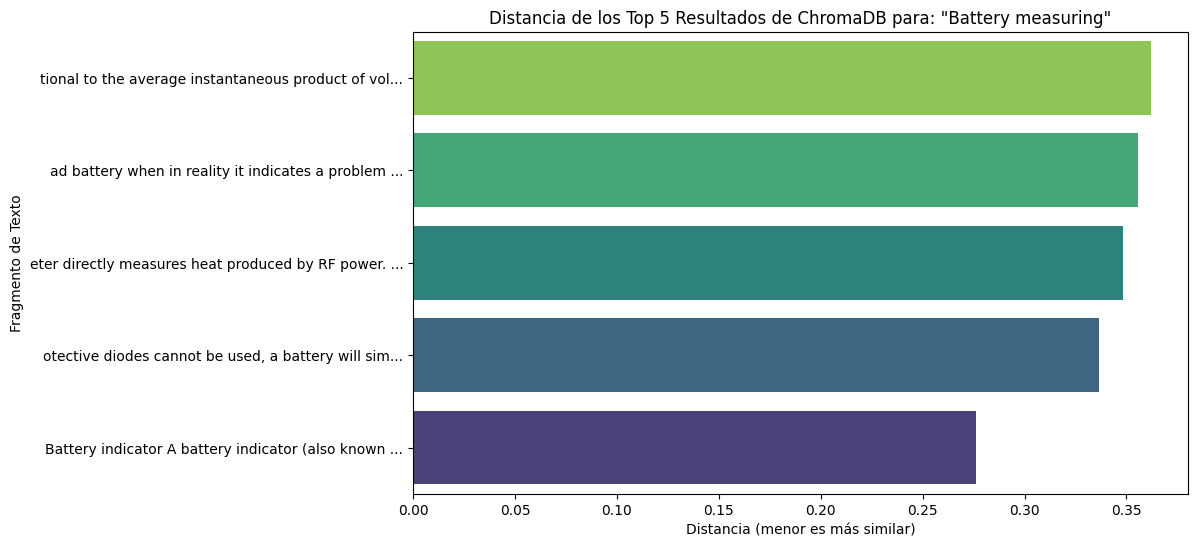

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_chroma_results(chroma_results, query_text):
    if not chroma_results or not chroma_results['distances'][0]:
        print("No hay resultados de ChromaDB para graficar.")
        return

    # ChromaDB devuelve distancias (menor es más similar)
    distances = chroma_results['distances'][0]
    # Los documentos son los textos
    result_texts = [doc[:50] + '...' for doc in chroma_results['documents'][0]]

    # Obtenemos el número de resultados para el título
    num_results = len(distances)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=distances, y=result_texts, hue=result_texts, palette='viridis', legend=False)
    plt.title(f'Distancia de los Top {num_results} Resultados de ChromaDB para: "{query_text}"')
    plt.xlabel('Distancia (menor es más similar)')
    plt.ylabel('Fragmento de Texto')
    plt.gca().invert_yaxis() # Invertir el eje Y para que el más similar (menor distancia) esté arriba
    plt.show()

# Asumiendo que 'res_chroma' contiene los resultados de ChromaDB
# y 'query_text' está definido
if 'res_chroma' in locals():
    plot_chroma_results(res_chroma, query_text)
else:
    print("La variable 'res_chroma' de los resultados de ChromaDB no está disponible. Asegúrate de ejecutar la celda de ChromaDB primero.")

1. ¿Qué tan fácil fue implementar todo comparado con Qdrant/Milvus?

ChromaDB fue notablemente más fácil y rápido de implementar para prototipado, con una API muy intuitiva en entornos locales.

2. ¿Qué limitaciones ves para un sistema en producción?

Para producción, ChromaDB (en modo local) tiene limitaciones en escalabilidad masiva, rendimiento con altos volúmenes/concurrencia, y características avanzadas de persistencia/replicación comparado con soluciones distribuidas.


## Parte 7 — SQL + vectores: PostgreSQL/pgvector (vector search transparente)

### Objetivo
Guardar embeddings en una tabla y ejecutar una consulta SQL de similitud.

### Qué debes implementar
1. Conectar a una base PostgreSQL con `pgvector` habilitado.
2. Crear una tabla (ej. `documents`) con:
   - `id` (PK)
   - `text` (texto)
   - `embedding` (vector(D))
   - metadata (columnas adicionales)
3. Insertar todos los documentos y embeddings.
4. Consultar Top-k por similitud, ordenando por distancia.

### Fórmula conceptual (lo que implementa tu SQL)
Para una consulta `q`, buscas:
$$ argmin_d \in D \; \text{dist}(\vec{q}, \vec{d})$$
donde `dist` puede ser L2 o una variante para cosine (según configuración).

### Entregable
- Función `pgvector_search(query_embedding, k)` que ejecute SQL y devuelva:
  - id, score/distancia, text, metadata

### Preguntas
- ¿Qué tan “explicable” te parece esta aproximación vs las otras?
- ¿Qué ventajas ofrece el mundo SQL (JOIN, filtros, agregaciones)?
- ¿Qué limitaciones esperas en escalabilidad frente a bases vectoriales dedicadas?


In [21]:
#Traer PostgreSQL a nuestro Colab
%%bash
# 1. Instalar PostgreSQL por defecto del sistema y herramientas de compilación
sudo apt-get update -qq
sudo apt-get install -y postgresql postgresql-contrib postgresql-server-dev-all git make gcc > /dev/null

# 2. Iniciar el servicio de PostgreSQL
sudo service postgresql start

# 3. Descargar, compilar e instalar pgvector desde el código fuente oficial
cd /tmp
git clone --branch v0.7.4 https://github.com/pgvector/pgvector.git > /dev/null 2>&1
cd pgvector
make > /dev/null
sudo make install > /dev/null

# 4. Configurar el usuario 'postgres' con la contraseña para tu script
sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'colab123';"

 * Starting PostgreSQL 14 database server
   ...done.
ALTER ROLE


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 41.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


In [22]:
!pip install psycopg2-binary pgvector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 66.5 MB/s eta 0:00:00


In [23]:
import psycopg2
from pgvector.psycopg2 import register_vector
from google.colab import userdata
import time
from tqdm.auto import tqdm

# 1. Configuración de conexión DIRECTA al localhost de Colab (socat se encarga del resto)
DB_PARAMS = {
    "dbname": "postgres",
    "user": "postgres",
    "password": "colab123",
    "host": "127.0.0.1",
    "port": 5432                           # El puerto que habilitamos con socat
}

COLLECTION_NAME = "wikipedia_chunks"
VECTOR_SIZE = embeddings.shape[1]

# Conectar al puente de la base de datos
print("Conectando al PostgreSQL de tu Docker a través del puente...")
conn = psycopg2.connect(**DB_PARAMS)
conn.autocommit = True
cur = conn.cursor()
print("¡Conexión establecida con éxito!")

# 2. Inicializar la extensión y crear la tabla
cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
register_vector(conn)

# Limpiar tabla si ya existe
cur.execute(f"DROP TABLE IF EXISTS {COLLECTION_NAME};")

# Crear la tabla con la columna de tipo vector(D)
create_table_query = f"""
CREATE TABLE {COLLECTION_NAME} (
    id INT PRIMARY KEY,
    text TEXT,
    doc_id INT,
    embedding vector({VECTOR_SIZE})
);
"""
cur.execute(create_table_query)

# 3. Insertar datos en batches
batch_size = 1000
print("\nInsertando datos en PostgreSQL (pgvector)...")

insert_query = f"""
INSERT INTO {COLLECTION_NAME} (id, text, doc_id, embedding)
VALUES (%s, %s, %s, %s);
"""

for i in tqdm(range(0, len(chunks_df), batch_size)):
    batch_df = chunks_df.iloc[i : i + batch_size]
    batch_vectors = embeddings[i : i + batch_size].tolist()

    insert_data = []
    for (idx, row), vec in zip(batch_df.iterrows(), batch_vectors):
        insert_data.append((
            int(idx),
            str(row["text"]),
            int(row["doc_id"]),
            vec
        ))

    cur.executemany(insert_query, insert_data)

# Crear el índice HNSW para optimizar búsquedas masivas
print("\nCreando índice HNSW para optimizar búsquedas...")
cur.execute(f"""
CREATE INDEX ON {COLLECTION_NAME}
USING hnsw (embedding vector_cosine_ops);
""")

# 4. Función de búsqueda vectorial
def pgvector_search(query_embedding, k=5):
    start_time = time.time()
    vector_list = query_embedding.flatten().tolist()

    # 💡 Agregamos '::vector' después del '%s' para que Postgres entienda el tipo de dato
    search_query = f"""
    SELECT id, embedding <=> %s::vector AS distance, text, doc_id
    FROM {COLLECTION_NAME}
    ORDER BY distance ASC
    LIMIT %s;
    """

    cur.execute(search_query, (vector_list, k))
    results = cur.fetchall()
    duration = time.time() - start_time

    formatted_results = []
    for row in results:
        idx, distance, text, doc_id = row
        score = 1.0 - distance
        metadata = {"doc_id": doc_id}
        formatted_results.append((idx, score, text, metadata))

    return formatted_results, duration

# 5. Ejecución y Prueba del experimento
print(f"\nResultados pgvector para: '{query_text}'")
res, duration = pgvector_search(query_vec, k=5)

for i, (idx, score, text, meta) in enumerate(res):
    print(f"\n[{i+1}] Similitud Coseno: {score:.4f} | ID: {idx} | Meta: {meta}")
    print(f"Texto: {text[:150]}...")
print(f"\nBúsqueda completada en: {duration:.4f} seconds")

# Cerrar conexiones al terminar
cur.close()
conn.close()

Conectando al PostgreSQL de tu Docker a través del puente...
¡Conexión establecida con éxito!

Insertando datos en PostgreSQL (pgvector)...


  0%|          | 0/80 [00:00<?, ?it/s]


Creando índice HNSW para optimizar búsquedas...

Resultados pgvector para: 'Battery measuring'

[1] Similitud Coseno: 0.8703 | ID: 10176 | Meta: {'doc_id': 1391}
Texto: Battery tester A battery tester is an electronic device intended for testing the state of an electric battery, going from a simple device for testing ...

[2] Similitud Coseno: 0.8618 | ID: 1 | Meta: {'doc_id': 1}
Texto: Battery indicator A battery indicator (also known as a battery gauge) is a device which gives information about a battery. This will usually be a visu...

[3] Similitud Coseno: 0.8401 | ID: 10177 | Meta: {'doc_id': 1391}
Texto: ing procedure, according to the type of battery being tested, such as the â€œ421â€ test for lead-acid vehicle batteries. Their common principle is ba...

[4] Similitud Coseno: 0.8391 | ID: 37406 | Meta: {'doc_id': 5067}
Texto: ils. One was connected via a series resistor to the battery supply. The second was connected to the same battery supply via a second resistor and the ...

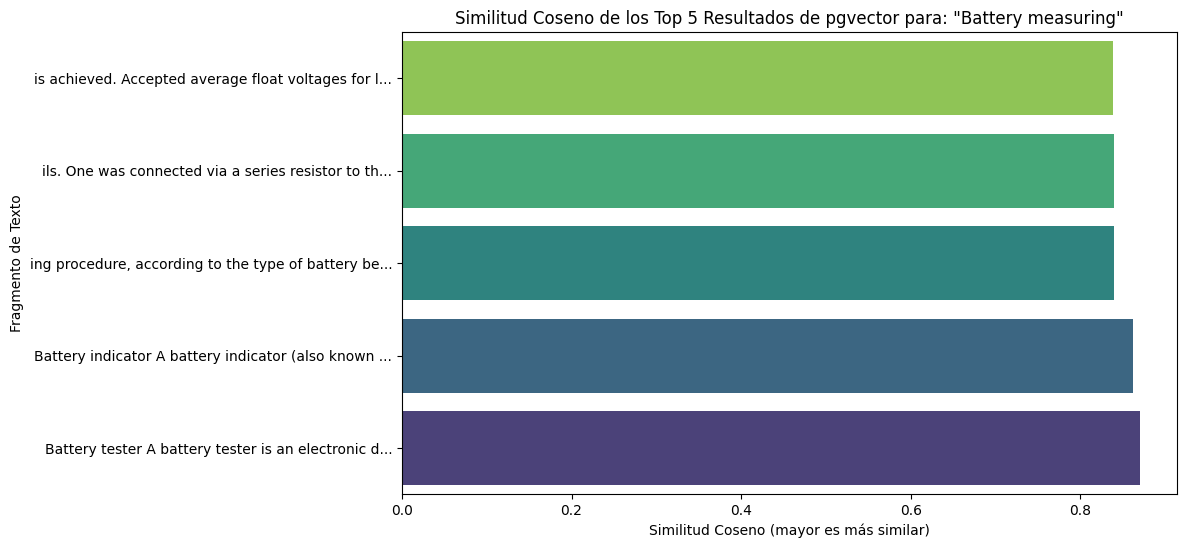

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pgvector_results(pgvector_results, query_text):
    if not pgvector_results:
        print("No hay resultados de pgvector para graficar.")
        return

    # pgvector_results es una lista de (id, score, text, metadata)
    scores = [item[1] for item in pgvector_results]
    # Obtener los textos correspondientes para las etiquetas, truncando para que no sean demasiado largos
    result_texts = [item[2][:50] + '...' for item in pgvector_results]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=scores, y=result_texts, hue=result_texts, palette='viridis', legend=False)
    plt.title(f'Similitud Coseno de los Top {len(pgvector_results)} Resultados de pgvector para: "{query_text}"')
    plt.xlabel('Similitud Coseno (mayor es más similar)')
    plt.ylabel('Fragmento de Texto')
    plt.gca().invert_yaxis() # Invertir el eje Y para que el más similar (mayor score) esté arriba
    plt.show()

# Asumiendo que 'res' contiene los resultados de pgvector_search
# y 'query_text' está definido
if 'res' in locals():
    plot_pgvector_results(res, query_text)
else:
    print("La variable 'res' de los resultados de pgvector no está disponible. Asegúrate de ejecutar la celda de pgvector primero.")

### Preguntas
- ¿Qué tan “explicable” te parece esta aproximación vs las otras?

Los embeddings son una columna más en una tabla SQL, la lógica de búsqueda es transparente vía operadores SQL, facilitando auditoría y depuración.

- ¿Qué ventajas ofrece el mundo SQL (JOIN, filtros, agregaciones)?

JOINs para enriquecer resultados, filtros potentes sobre cualquier columna (búsquedas híbridas), agregaciones para análisis, ACID para integridad, y un ecosistema maduro de herramientas SQL.

- ¿Qué limitaciones esperas en escalabilidad frente a bases vectoriales dedicadas?

Limitaciones: Indexación a escala extrema (billones de vectores) es más eficiente en Vector DBs dedicados. Gestión de recursos y latencia en altas cargas pueden ser menos optimizadas que en bases puramente vectoriales. También, menos operaciones especializadas sobre vectores.
